# GTSRB: Data Exploration and Preparation

This notebook explores the German Traffic Sign Recognition Benchmark (GTSRB) dataset and prepares the images for model training.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter

## 1. Dataset Loading

Load the GTSRB training images and their corresponding class labels.

In [2]:
DATA_DIR = Path("../data/raw")
train_dir = DATA_DIR / "Train"
print(f"Train directory: {train_dir}")

Train directory: ../data/raw/Train


## 2. Dataset Overview

Check the total number of images, classes, and class ID range.

In [3]:
image_extensions = {".png", ".jpg", ".jpeg"}

image_paths = []
labels = []

for class_dir in sorted(train_dir.iterdir()):
    if not class_dir.is_dir() or not class_dir.name.isdigit():
        continue

    class_id = int(class_dir.name)

    for image_path in class_dir.iterdir():
        if image_path.suffix.lower() in image_extensions:
            image_paths.append(image_path)
            labels.append(class_id)

data = pd.DataFrame({
    "image_path": image_paths,
    "class_id": labels
})

print(f"Total images: {len(data):,}")
print(f"Total classes: {data['class_id'].nunique()}")
class_ids = sorted(data["class_id"].unique())

print(f"Class IDs: {int(class_ids[0])} to {int(class_ids[-1])}")

Total images: 39,209
Total classes: 43
Class IDs: 0 to 42


In [4]:
class_counts = (
    data["class_id"]
    .value_counts()
    .sort_index()
)

class_counts.to_frame(name="image_count")

,image_count
class_id,
0,210
1,2220
2,2250
3,1410
4,1980
5,1860
6,420
7,1440
8,1410


In [5]:
print(f"Minimum images per class: {class_counts.min():,}")
print(f"Maximum images per class: {class_counts.max():,}")
print(f"Mean images per class: {class_counts.mean():.2f}")

Minimum images per class: 210
Maximum images per class: 2,250
Mean images per class: 911.84


## 2. Dataset Overview

Check the total number of images, classes, and class ID range.

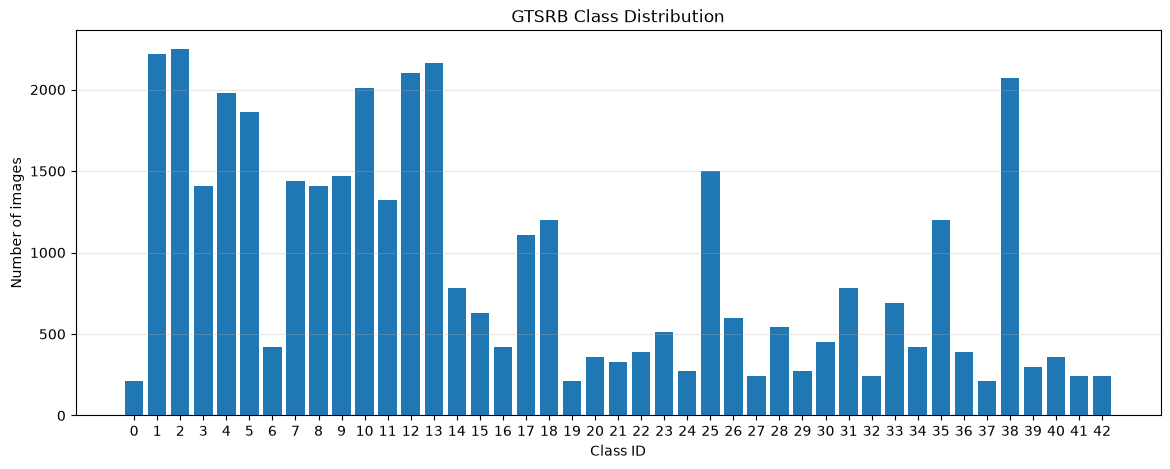

In [6]:
plt.figure(figsize=(14, 5))

plt.bar(class_counts.index, class_counts.values)

plt.xlabel("Class ID")
plt.ylabel("Number of images")
plt.title("GTSRB Class Distribution")
plt.xticks(range(43))
plt.grid(axis="y", alpha=0.3)

plt.show()

## 4. Samples from Each Class

Visualize one sample image from each GTSRB class.

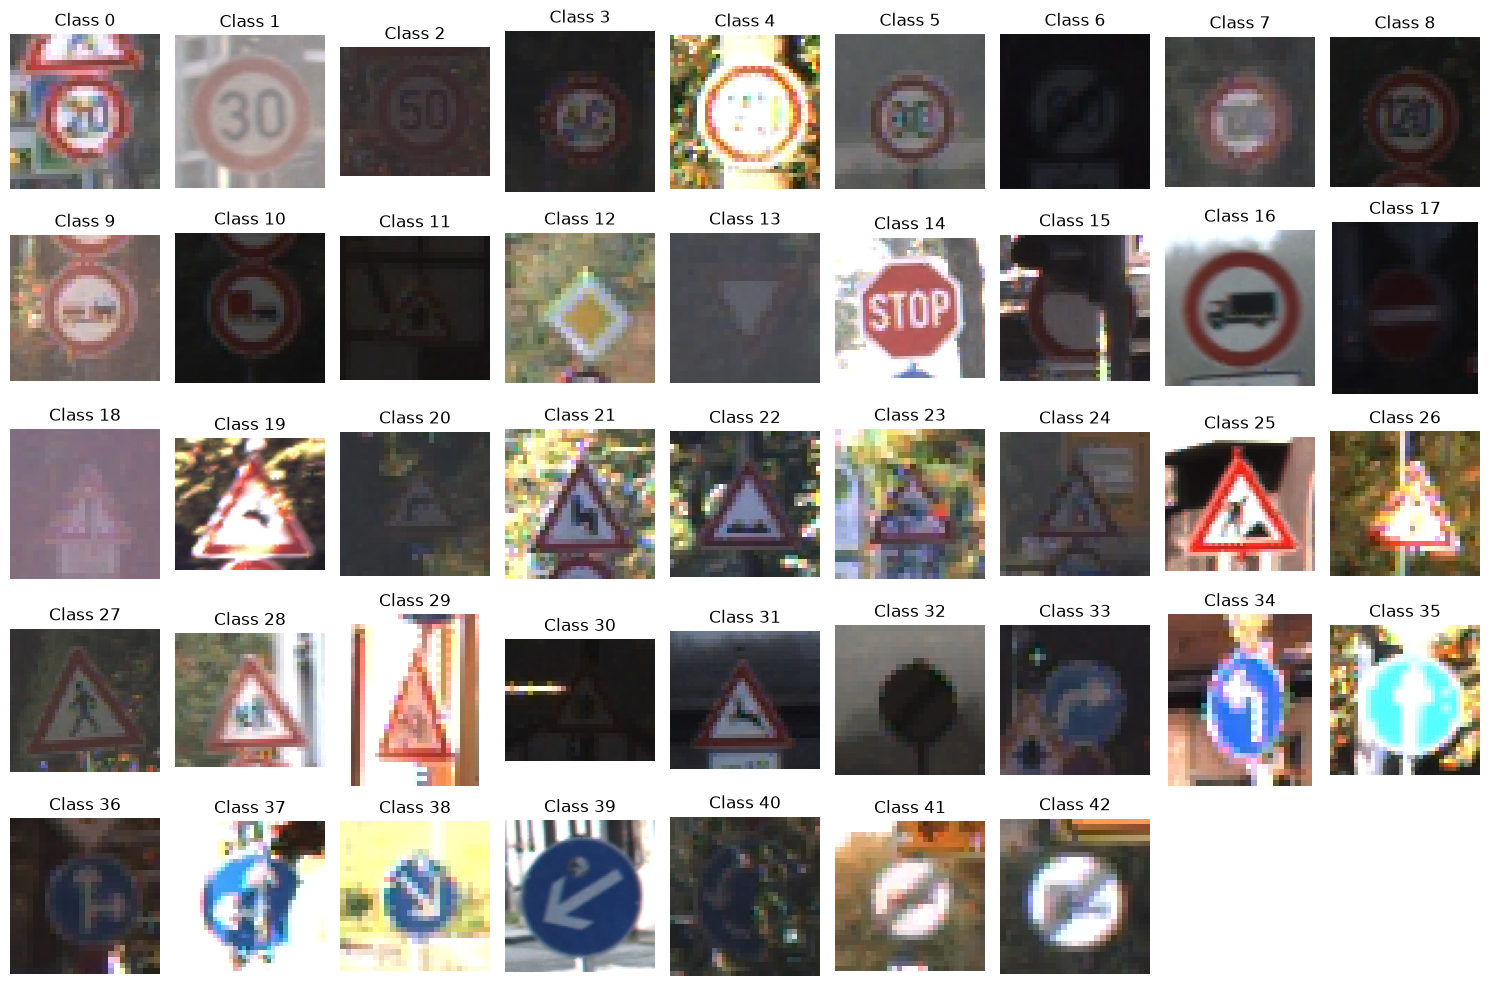

In [7]:
samples = data.groupby("class_id").first().reset_index()

fig, axes = plt.subplots(5, 9, figsize=(15, 10))

for ax, (_, row) in zip(axes.flat, samples.iterrows()):
    image = Image.open(row["image_path"]).convert("RGB")

    ax.imshow(image)
    ax.set_title(f"Class {row['class_id']}")
    ax.axis("off")

for ax in axes.flat[len(samples):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## 5. Image Dimensions

Analyze the relationship between image width and height and inspect the different original image sizes.

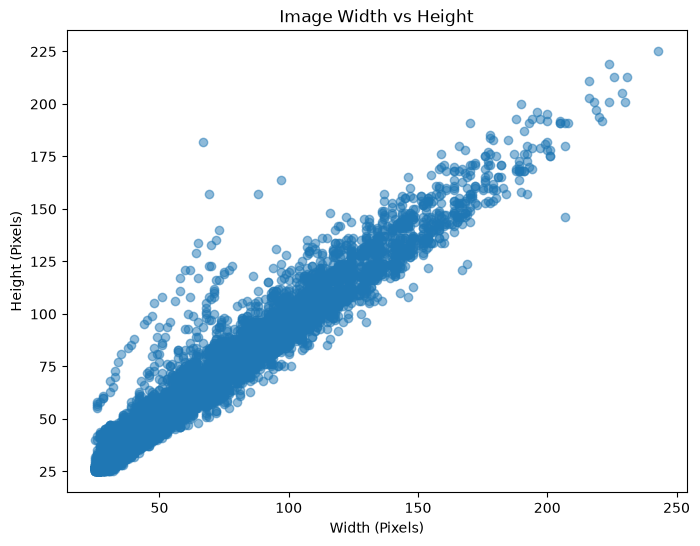

In [8]:
widths = []
heights = []

for image_path in data["image_path"]:
    with Image.open(image_path) as image:
        width, height = image.size
        widths.append(width)
        heights.append(height)

plt.figure(figsize=(8, 6))

plt.scatter(widths, heights, alpha=0.5)

plt.xlabel("Width (Pixels)")
plt.ylabel("Height (Pixels)")
plt.title("Image Width vs Height")

plt.show()

## 6. Pixel Value Analysis

Inspect the shape, data type, range, mean, and standard deviation of pixel values.

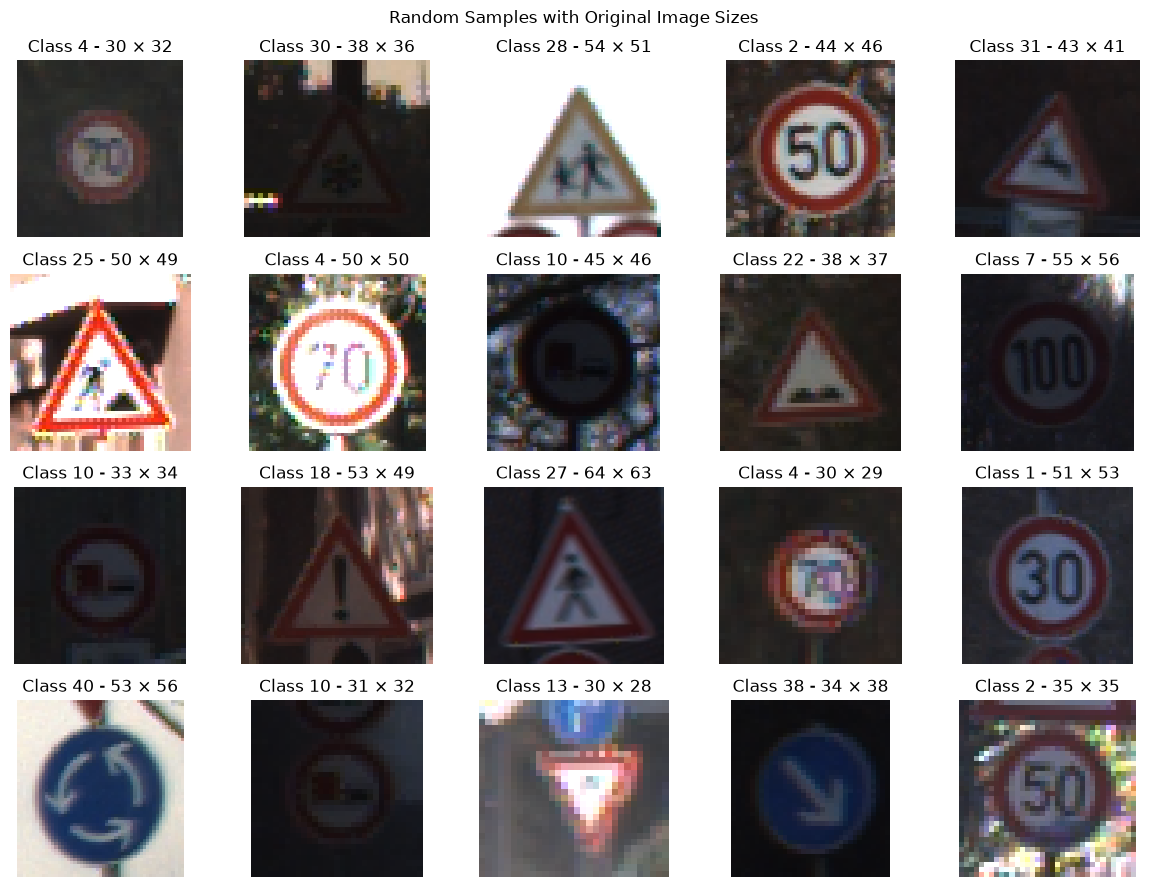

In [9]:
samples = data.sample(20, random_state=42)

fig, axes = plt.subplots(4, 5, figsize=(12, 9))

for ax, (_, row) in zip(axes.flat, samples.iterrows()):
    image = Image.open(row["image_path"]).convert("RGB")

    ax.imshow(image)
    ax.set_title(f"Class {row['class_id']} - {image.size[0]} × {image.size[1]}")
    ax.axis("off")

plt.suptitle("Random Samples with Original Image Sizes")
plt.tight_layout()
plt.show()

In [10]:
sample_image = Image.open(data.iloc[0]["image_path"]).convert("RGB")
sample_array = np.array(sample_image)

print(f"Image shape: {sample_array.shape}")
print(f"Data type: {sample_array.dtype}")
print(f"Minimum pixel value: {sample_array.min()}")
print(f"Maximum pixel value: {sample_array.max()}")
print(f"Mean pixel value: {sample_array.mean()}")
print(f"Median pixel value: {np.median(sample_array)}")
print(f"Standard deviation of pixel values: {sample_array.std()}")

Image shape: (30, 29, 3)
Data type: uint8
Minimum pixel value: 31
Maximum pixel value: 255
Mean pixel value: 128.58850574712645
Median pixel value: 115.0
Standard deviation of pixel values: 50.89967615450131


## 7. EDA Summary

Summarize the main findings from the dataset exploration.

In [11]:
unique_sizes = len(set(zip(widths, heights)))

print(f"Total images: {len(data):,}")
print(f"Number of classes: {data['class_id'].nunique()}")
print(f"Smallest class: {class_counts.idxmin()}")
print(f"Smallest class count: {class_counts.min():,}")
print(f"Largest class: {class_counts.idxmax()}")
print(f"Largest class count: {class_counts.max():,}")
print(f"Number of unique image sizes: {unique_sizes}")
print(f"Sample image shape: {sample_array.shape}")

Total images: 39,209
Number of classes: 43
Smallest class: 0
Smallest class count: 210
Largest class: 2
Largest class count: 2,250
Number of unique image sizes: 2924
Sample image shape: (30, 29, 3)


### Key Findings

- The dataset contains 43 traffic sign classes.
- The number of images varies considerably between classes.
- The original images have different dimensions.
- Pixel values are stored as RGB values.
- Images will need to be resized and normalized before model training.